# micrograd — building an autograd engine from scratch

Combined and cleaned-up notes from Karpathy's *Neural Networks: Zero to Hero*, parts 1 and 2.

---

### The idea in one paragraph

**Autograd = automatic gradient.** **Backpropagation** is what lets us efficiently evaluate the gradient of some loss function with respect to the weights. A gradient answers: *given a nudge to this input, how much does the output change?* — it is a slope.

Everything here is built out of one small class, `Value`, which wraps a single number and remembers how it was produced. That memory is what makes the backward pass possible.

## 0. Setup

In [1]:
import math
import random

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
# Part 1 — from derivatives to a working engine

## 1. What a derivative actually is

Before any neural network: take a simple function and measure its slope numerically, by nudging the input by a tiny `h` and seeing how much the output moves.

In [2]:
def f(x):
    return 3 * x**2 - 4 * x + 5


f(3.0)

20.0

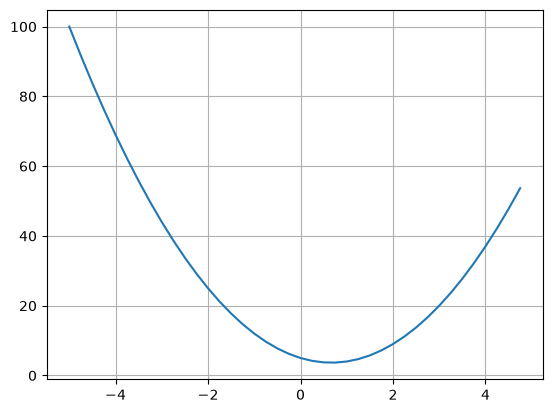

In [3]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
plt.grid()

### Numerical derivative at three points

Same recipe each time: `(f(x + h) - f(x)) / h`. Watch the sign and magnitude change.

In [4]:
# positive slope: the function is climbing here
h = 0.00001
x = 3.0
print(f(x))
print(f(x + h))
print((f(x + h) - f(x)) / h)

20.0
20.0001400003
14.00003000000538


In [5]:
# negative slope: the function is falling here
h = 0.00001
x = -3.0
print(f(x))
print(f(x + h))
print((f(x + h) - f(x)) / h)

44.0
43.9997800003
-21.999970000052823


In [6]:
# slope ~ 0 at the minimum: a tiny change has (almost) no effect on the output
h = 0.00001
x = 2 / 3
print(f(x))
print(f(x + h))
print((f(x + h) - f(x)) / h)

3.666666666666667
3.666666666966667
3.0000002482211127e-05


## 2. More than one input

With several inputs, "the derivative" becomes one slope *per input* — the partial derivative. Nudge one variable at a time and hold the rest fixed.

In [7]:
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [8]:
# slope of d with respect to a  ->  should come out as b
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
a += h
d2 = a * b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [9]:
# slope of d with respect to b  ->  should come out as a
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
b += h
d2 = a * b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


### The two rules that do most of the work

This is the pattern the numerical experiments above just confirmed, and it's what the `_backward` functions encode:

| operation | gradient flowing to each input |
|---|---|
| **addition** `c = a + b` | **1** — the gradient passes straight through, unchanged |
| **multiplication** `c = a * b` | **the other value** — `a` gets `b`, `b` gets `a` |

Multiplication routes the *other* operand's value; addition simply distributes.

## 3. The `Value` class

One scalar, plus enough bookkeeping to walk backwards through the graph that produced it.

Two details worth pausing on:

- `self.grad += ...` — gradients **accumulate** with `+=`, never `=`. If a value is used more than once, each use contributes, and they must sum. (Demonstrated in §7.)
- `backward()` sorts the graph **topologically** so that every node is processed only after everything downstream of it, then seeds `self.grad = 1.0` and walks the list in reverse.

In [10]:
class Value:
    """A scalar value plus the machinery to backpropagate through it.

    Built up across the two videos:
      part 1 -> data, grad, _prev/_op bookkeeping, __add__, __mul__, tanh, backward
      part 2 -> __pow__, __neg__, __sub__, __truediv__, the __r*__ reflected ops
                (so `2*n` and `n - 1` work), and exp
    """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0            # d(final output) / d(self); starts at "no influence"
        self._backward = lambda: None   # local chain-rule step, filled in by each op
        self._prev = set(_children)     # who produced me
        self._op = _op                  # what operation produced me
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    # ---- core ops -------------------------------------------------------
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # addition passes the gradient straight through, unchanged
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            # multiplication swaps: each input's gradient is the *other* value
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    # ---- conveniences built on top of the core ops ----------------------
    def __rmul__(self, other):       # other * self
        return self * other

    def __truediv__(self, other):    # self / other
        return self * other ** -1

    def __neg__(self):               # -self
        return self * -1

    def __sub__(self, other):        # self - other
        return self + (-other)

    def __radd__(self, other):       # other + self
        return self + other

    # ---- activations ----------------------------------------------------
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad   # d/dx e^x = e^x = out.data
        out._backward = _backward
        return out

    # ---- backprop -------------------------------------------------------
    def backward(self):
        # topological order: every node comes after all of its inputs
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0                  # seed: d(self)/d(self) = 1
        for node in reversed(topo):      # walk backwards, applying the chain rule
            node._backward()

## 4. Drawing the graph

`draw_dot` renders the expression as a left-to-right graph with each node's `data` and `grad`, which makes the backward pass legible.

In [11]:
from graphviz import Digraph


def trace(root):
    """Collect every node and edge reachable backwards from root."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root):
    """Render the computational graph left-to-right, showing data and grad."""
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,
                 label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
                 shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

## 5. Checking backprop against a numerical estimate

Build a small expression `L = (a*b + c) * f`, nudge one intermediate node by `h`, and confirm the measured slope matches what backprop will report.

In [12]:
def lol():
    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    e.data += h                 # <-- nudge e
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print('numerical dL/de:', (L2 - L1) / h)
    return L


lol()

numerical dL/de: -2.000000000000668


Value(data=-8.002)

### Now let the engine do it

Rebuild the expression, call `backward()` once, and read every gradient off the graph.

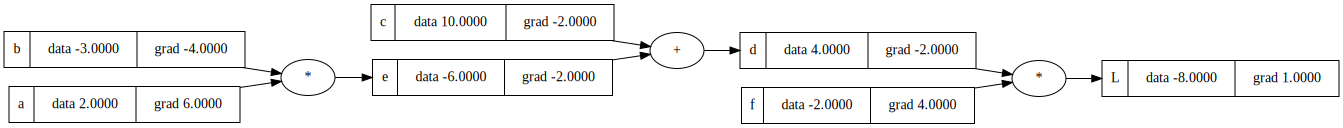

In [13]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

L.backward()
draw_dot(L)

### One step of gradient *ascent*

Nudge each leaf a little way **along** its gradient and `L` should go up. (Training later does the opposite — steps against the gradient, to push a loss down.)

> **Note:** in the original part-1 notebook this cell sat *before* `L.backward()`, so every `.grad` was still `0.0` and the update did nothing. It has to come after the backward pass.

In [14]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


## 6. A single neuron

**Bias** shifts the neuron's output up or down independently of the inputs — it makes the neuron more or less *trigger happy*, i.e. quicker or slower to activate.

The **activation function** takes that weighted sum and squashes it into a bounded range. `tanh` flattens very large values toward `+1`, very negative values toward `-1`, and leaves `0` at `0`.

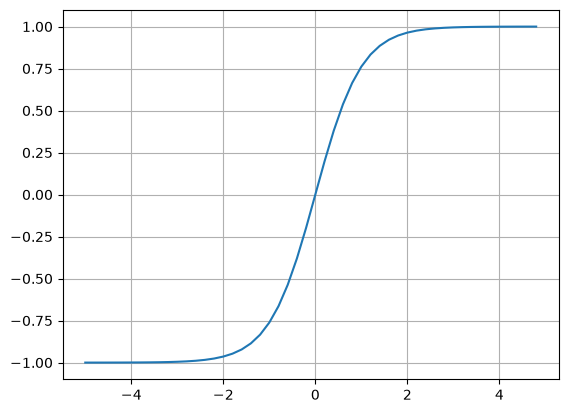

In [15]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

Two inputs, two weights, a bias, and a tanh — one neuron end to end.

> The original cell called this "a convolutional neural network cell." It isn't convolutional — it's a single **neuron** (a perceptron with a tanh activation). Convolution is a separate idea: sliding a shared filter over spatial patches. Renamed here to avoid the mix-up later.

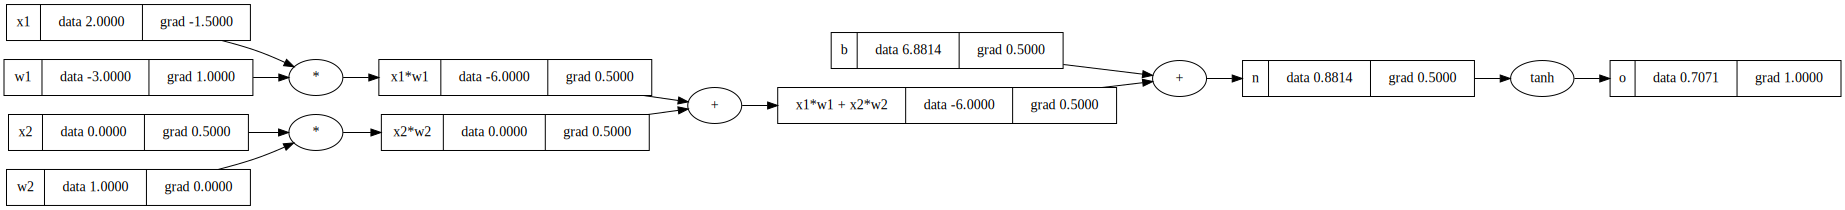

In [16]:
# a single neuron: two inputs, two weights, a bias, tanh activation
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')  # hand-picked so the numbers come out clean
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()
draw_dot(o)

## 7. Why gradients accumulate (`+=`, not `=`)

If a node feeds into the graph more than once, each path contributes a gradient and they must **sum**. With `=` the second path would silently overwrite the first.

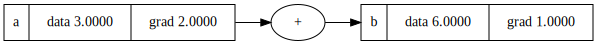

In [17]:
# a is used twice -> db/da = 1 + 1 = 2, not 1
a = Value(3.0, label='a')
b = a + a; b.label = 'b'

b.backward()
draw_dot(b)

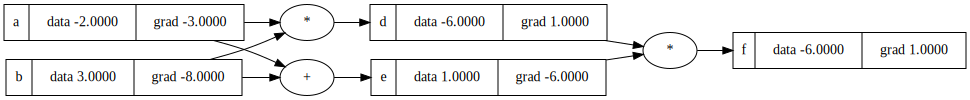

In [18]:
# a and b each feed two different branches that later recombine
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()
draw_dot(f)

---
# Part 2 — from one neuron to a trained network

## 8. tanh, decomposed

`tanh` was implemented as a single fused op. Nothing forces that: written out as `(e^{2n} - 1)/(e^{2n} + 1)` it becomes several finer-grained ops, and backprop still produces identical gradients at the leaves.

The lesson: how coarsely you chop the graph is your choice — you only need the local derivative of whatever pieces you define. (This is what the extra `__sub__`, `__truediv__`, `__rmul__`, and `exp` on `Value` are for.)

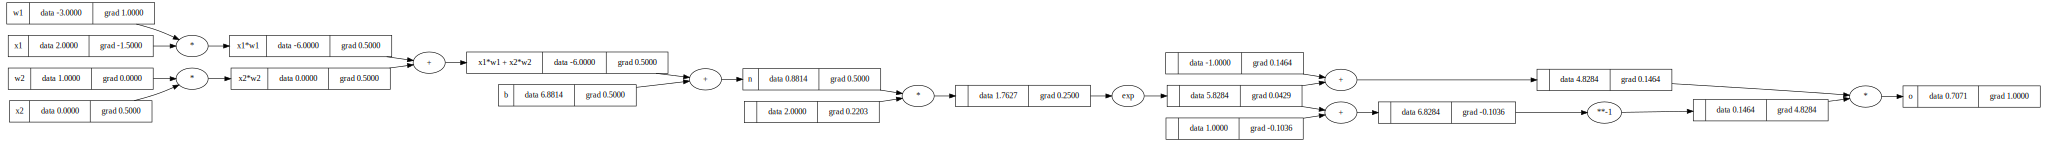

In [19]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ---- tanh, spelled out
e = (2 * n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'

o.backward()
draw_dot(o)

## 9. Sanity check against PyTorch

Same neuron, same numbers, using a real autograd library. The gradients should match what `Value` produced.

In [20]:
import torch

In [21]:
x1 = torch.Tensor([2.0]).double();               x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();               x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();              w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();               w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## 10. Neuron → Layer → MLP

Three small classes, each one a list of the thing below it. `parameters()` flattens out every weight and bias so training can reach them.

In [22]:
class Neuron:
    """One neuron: weighted sum of inputs, plus a bias, squashed by tanh."""

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w . x + b, then squash
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]


class Layer:
    """A row of independent neurons, all fed the same input."""

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    """Layers stacked back to back; each layer's output feeds the next."""

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

### Trying each piece

In [23]:
inputx = [2.0, 10.2]
n = Neuron(len(inputx))
n(inputx)

Value(data=-0.9999980442407813)

In [24]:
inputx = [2.0, 10.2]
n = Layer(len(inputx), 5)
n(inputx)

[Value(data=-0.24132336516750394),
 Value(data=0.9999933006668692),
 Value(data=0.09527380841462003),
 Value(data=-0.9999999794640292),
 Value(data=0.9999999988769787)]

In [25]:
inputx = [2.0, 10.2]
layer_sizes = [4, 4, 1]
n = MLP(len(inputx), layer_sizes)
n(inputx)

Value(data=-0.19222002075375702)

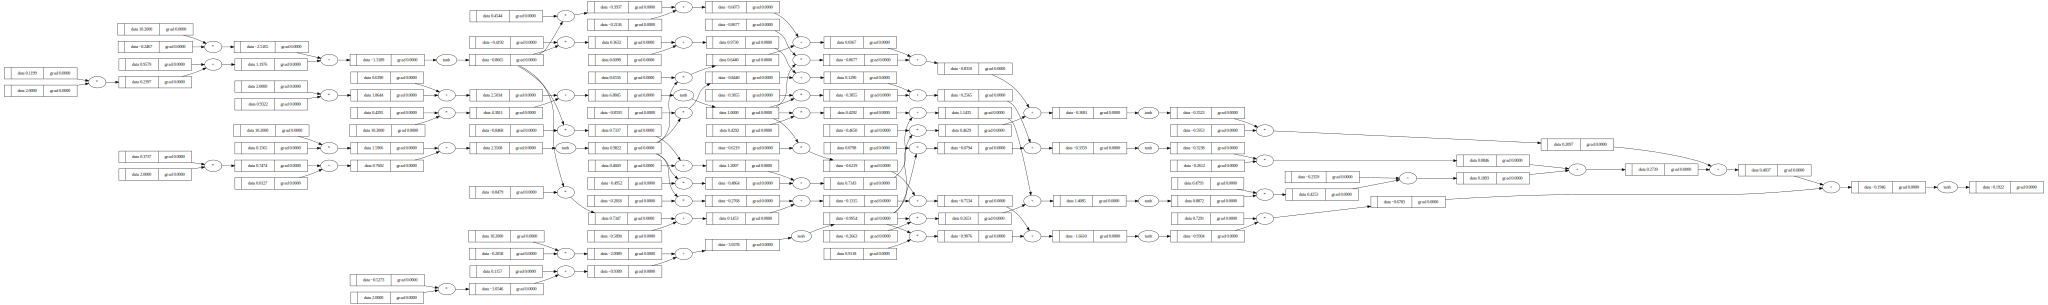

In [26]:
draw_dot(n(inputx))

## 11. A tiny binary classifier

Four examples, four desired targets. The network currently outputs whatever its random initialization gives.

In [27]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]   # desired targets

n = MLP(3, [4, 4, 1])         # 3 inputs -> 4 -> 4 -> 1 output
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.11192562842637631),
 Value(data=0.7310404106302381),
 Value(data=0.5297267414549568),
 Value(data=0.48558899885659534)]

### Loss

Sum of squared errors: zero when every prediction matches its target, and growing the further off they are. A single number to push downhill.

In [28]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=6.837562088006054)

In [29]:
loss.backward()

In [30]:
# every weight now knows how it influenced the loss
n.layers[0].neurons[0].w[0].grad

2.0329612502404633

In [31]:
len(n.parameters())

41

## 12. The training loop

Forward → backward → update, repeated. 

**The one easy mistake:** `p.grad = 0.0` before every backward pass. Gradients are *summed* (that `+=` from §7), so without clearing them each iteration's gradients pile on top of the last one's and the updates go wrong.

In [32]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0        # reset first: grad is summed, so stale values must be cleared
    loss.backward()

    # update: step *against* the gradient to push the loss down
    for p in n.parameters():
        p.data += -0.01 * p.grad     # 0.01 is the step size / learning rate

    print(k, loss.data)

0 6.837562088006054
1 6.091594661425436
2 5.239666504724617
3 4.344262319604499
4 3.54206825007195
5 2.9126153445431107
6 2.4378176862472167
7 2.0734425540516526
8 1.7863446919611536
9 1.5552647483244704
10 1.3662967255762595
11 1.2098776427602462
12 1.0791200263016731
13 0.968884815483003
14 0.8752403680648846
15 0.7951261935773137
16 0.7261304101133282
17 0.6663345125362566
18 0.6142007917817416
19 0.5684884819221824


In [33]:
ypred   # should now sit close to [1.0, -1.0, -1.0, 1.0]

[Value(data=0.6105904697131831),
 Value(data=-0.6285910054263418),
 Value(data=-0.6187169824281811),
 Value(data=0.6345860991901164)]

---
## Recap

| concept | what it means here |
|---|---|
| **autograd** | automatic gradient — the engine tracks operations so derivatives come for free |
| **gradient** | how much the output moves per unit nudge of an input; a slope |
| **backpropagation** | efficiently evaluating the gradient of a loss w.r.t. every weight, by walking the graph backwards with the chain rule |
| **addition rule** | gradient passes through unchanged (×1) |
| **multiplication rule** | each input receives the *other* input's value |
| **bias** | shifts the neuron's activation threshold — more or less trigger happy |
| **activation (tanh)** | squashing function: large → +1, very negative → −1, 0 → 0 |
| **`grad = 0` reset** | gradients accumulate with `+=`, so they must be cleared before each backward pass |
| **learning rate** | the step size in `p.data += -lr * p.grad` |
